In [17]:
# http://danielweitzenfeld.github.io/passtheroc/blog/2014/10/28/bayes-premier-league/
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [18]:
import os
import math
import warnings
warnings.filterwarnings('ignore')

from IPython.display import Image, HTML
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pymc

In [19]:
data_file = 'premier_league.txt'
df = pd.read_csv(data_file, sep='\t', index_col=0,)
df.head()

,ARS,AST,CAR,CHE,CRY,EVE,FUL,HUL,LIV,MCI,MUN,NEW,NOR,SOU,STK,SUN,SWA,TOT,WBA,WHU
Home ╲ Away,,,,,,,,,,,,,,,,,,,,
Arsenal,NaN,1–3,2–0,0–0,2–0,1–1,2–0,2–0,2–0,1–1,0–0,3–0,4–1,2–0,3–1,4–1,2–2,1–0,1–0,3–1
Aston Villa,1–2,NaN,2–0,1–0,0–1,0–2,1–2,3–1,0–1,3–2,0–3,1–2,4–1,0–0,1–4,0–0,1–1,0–2,4–3,0–2
Cardiff City,0–3,0–0,NaN,1–2,0–3,0–0,3–1,0–4,3–6,3–2,2–2,1–2,2–1,0–3,1–1,2–2,1–0,0–1,1–0,0–2
Chelsea,6–0,2–1,4–1,NaN,2–1,1–0,2–0,2–0,2–1,2–1,3–1,3–0,0–0,3–1,3–0,1–2,1–0,4–0,2–2,0–0
Crystal Palace,0–2,1–0,2–0,1–0,NaN,0–0,1–4,1–0,3–3,0–2,0–2,0–3,1–1,0–1,1–0,3–1,0–2,0–1,3–1,1–0


In [33]:
df.index = df.columns
rows = []
for i in df.index:
    for c in df.columns:
        if i == c: continue
        score = df.ix[i, c]
        uscore = score.decode('utf-8') # something strange is happening eith encoding in score. I'll hack for now
        ascore = uscore.encode('ascii','replace') 
        #score = [int(row) for row in score.split('-')]
        score = [int(row) for row in ascore.split('?')]
        rows.append([i, c, score[0], score[1]])
df = pd.DataFrame(rows, columns = ['home', 'away', 'home_score', 'away_score'])
df.head()

,home,away,home_score,away_score
0,ARS,AST,1,3
1,ARS,CAR,2,0
2,ARS,CHE,0,0
3,ARS,CRY,2,0
4,ARS,EVE,1,1


In [34]:
teams = df.home.unique()
teams = pd.DataFrame(teams, columns=['team'])
teams['i'] = teams.index
teams.head()

,team,i
0,ARS,0
1,AST,1
2,CAR,2
3,CHE,3
4,CRY,4


In [35]:
df = pd.merge(df, teams, left_on='home', right_on='team', how='left')
df = df.rename(columns = {'i': 'i_home'}).drop('team', 1)
df = pd.merge(df, teams, left_on='away', right_on='team', how='left')
df = df.rename(columns = {'i': 'i_away'}).drop('team', 1)
df.head()

,home,away,home_score,away_score,i_home,i_away
0,ARS,AST,1,3,0,1
1,ARS,CAR,2,0,0,2
2,ARS,CHE,0,0,0,3
3,ARS,CRY,2,0,0,4
4,ARS,EVE,1,1,0,5


In [36]:
observed_home_goals = df.home_score.values
observed_away_goals = df.away_score.values
home_team = df.i_home.values
away_team = df.i_away.values
num_teams = len(df.i_home.unique())
num_games = len(home_team)

In [37]:
g = df.groupby('i_away')
att_starting_points = np.log(g.away_score.mean())
g = df.groupby('i_home')
def_starting_points = -np.log(g.away_score.mean())

In [39]:
# hyperpriors
home = pymc.Normal('home', 0, .0001, value=0)
tau_att = pymc.Gamma('tau_att', .1, .1, value=10)
tau_def = pymc.Gamma('tau_def', .1, .1, value=10)
intercept = pymc.Normal('intercept', 0, .0001, value=0)

#team-specific parameters
atts_star = pymc.Normal("atts_star", 
                        mu=0, 
                        tau=tau_att, 
                        size=num_teams, 
                        value=att_starting_points.values)
defs_star = pymc.Normal("defs_star", 
                        mu=0, 
                        tau=tau_def, 
                        size=num_teams, 
                        value=def_starting_points.values) 

# trick to code the sum to zero contraint
@pymc.deterministic
def atts(atts_star=atts_star):
    atts = atts_star.copy()
    atts = atts - np.mean(atts_star)
    return atts

@pymc.deterministic
def defs(defs_star=defs_star):
    defs = defs_star.copy()
    defs = defs - np.mean(defs_star)
    return defs

@pymc.deterministic
def home_theta(home_team=home_team, 
               away_team=away_team, 
               home=home, 
               atts=atts, 
               defs=defs, 
               intercept=intercept): 
    return np.exp(intercept + 
                  home + 
                  atts[home_team] + 
                  defs[away_team])
  
@pymc.deterministic
def away_theta(home_team=home_team, 
               away_team=away_team, 
               home=home, 
               atts=atts, 
               defs=defs, 
               intercept=intercept): 
    return np.exp(intercept + 
                  atts[away_team] + 
                  defs[home_team])   


home_goals = pymc.Poisson('home_goals', 
                          mu=home_theta, 
                          value=observed_home_goals, 
                          observed=True)
away_goals = pymc.Poisson('away_goals', 
                          mu=away_theta, 
                          value=observed_away_goals, 
                          observed=True)

mcmc = pymc.MCMC([home, intercept, tau_att, tau_def, 
                  home_theta, away_theta, 
                  atts_star, defs_star, atts, defs, 
                  home_goals, away_goals])
map_ = pymc.MAP( mcmc )
map_.fit()
mcmc.sample(200000, 40000, 20)

 [-----------------100%-----------------] 200000 of 200000 complete in 218.9 sec

Plotting home


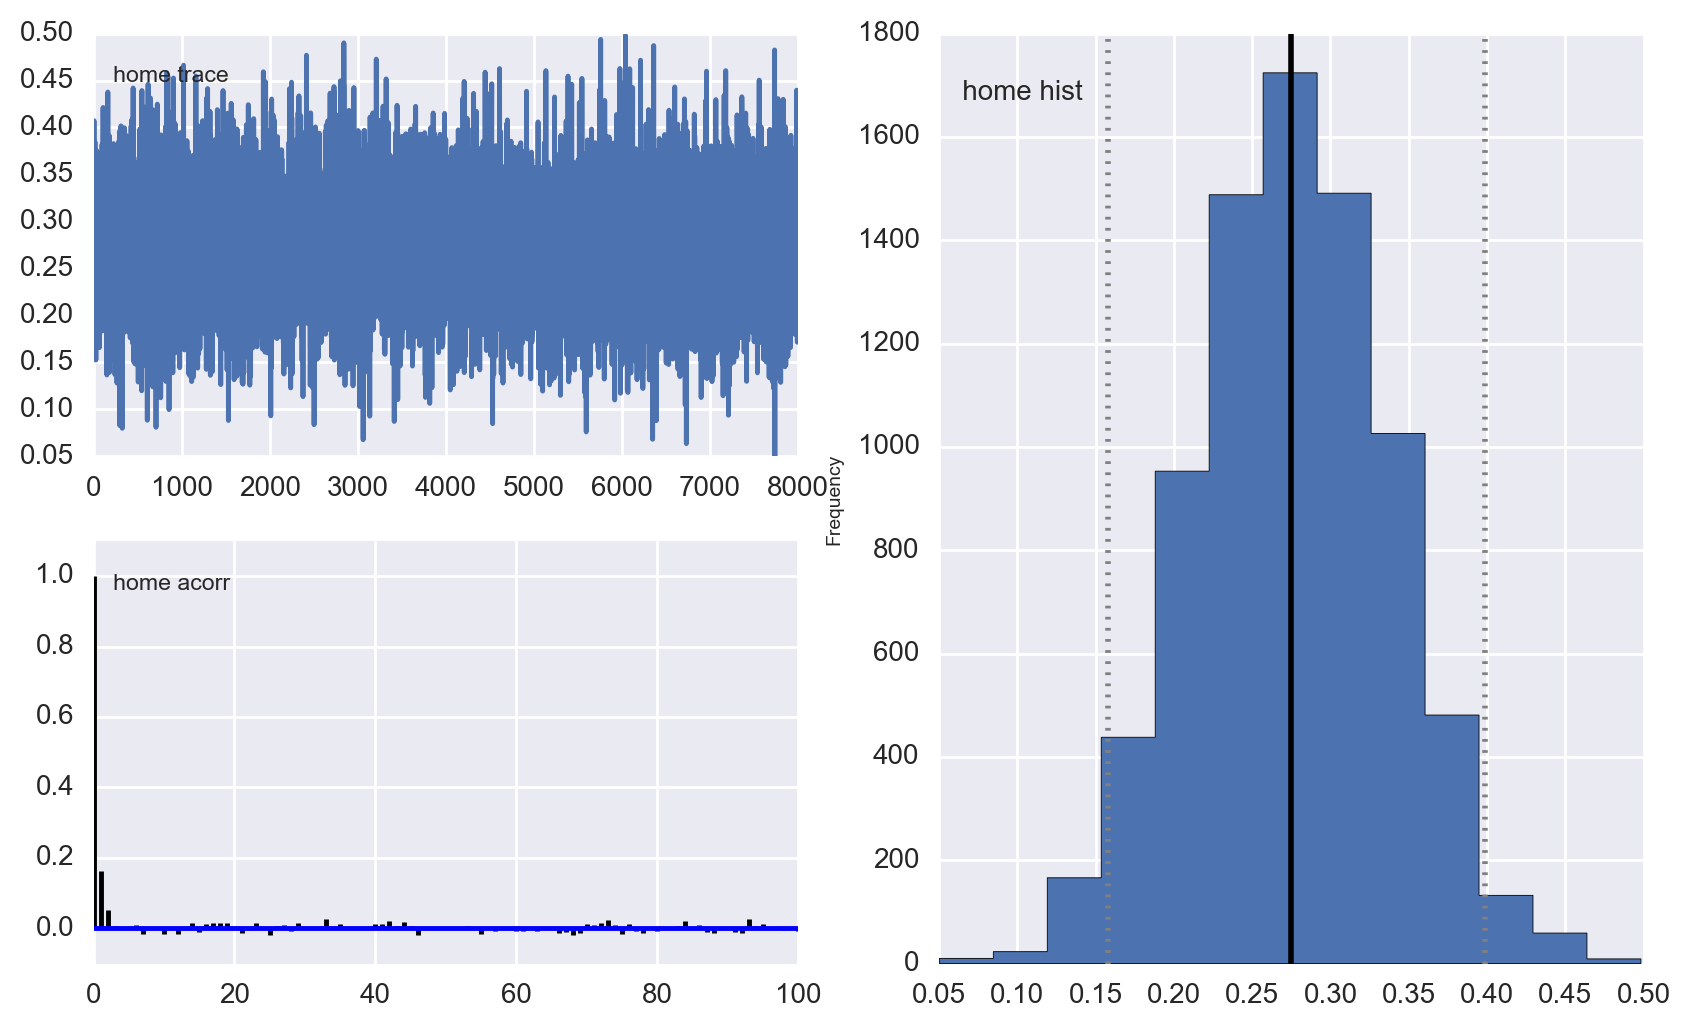

In [40]:
pymc.Matplot.plot(home)

Plotting intercept


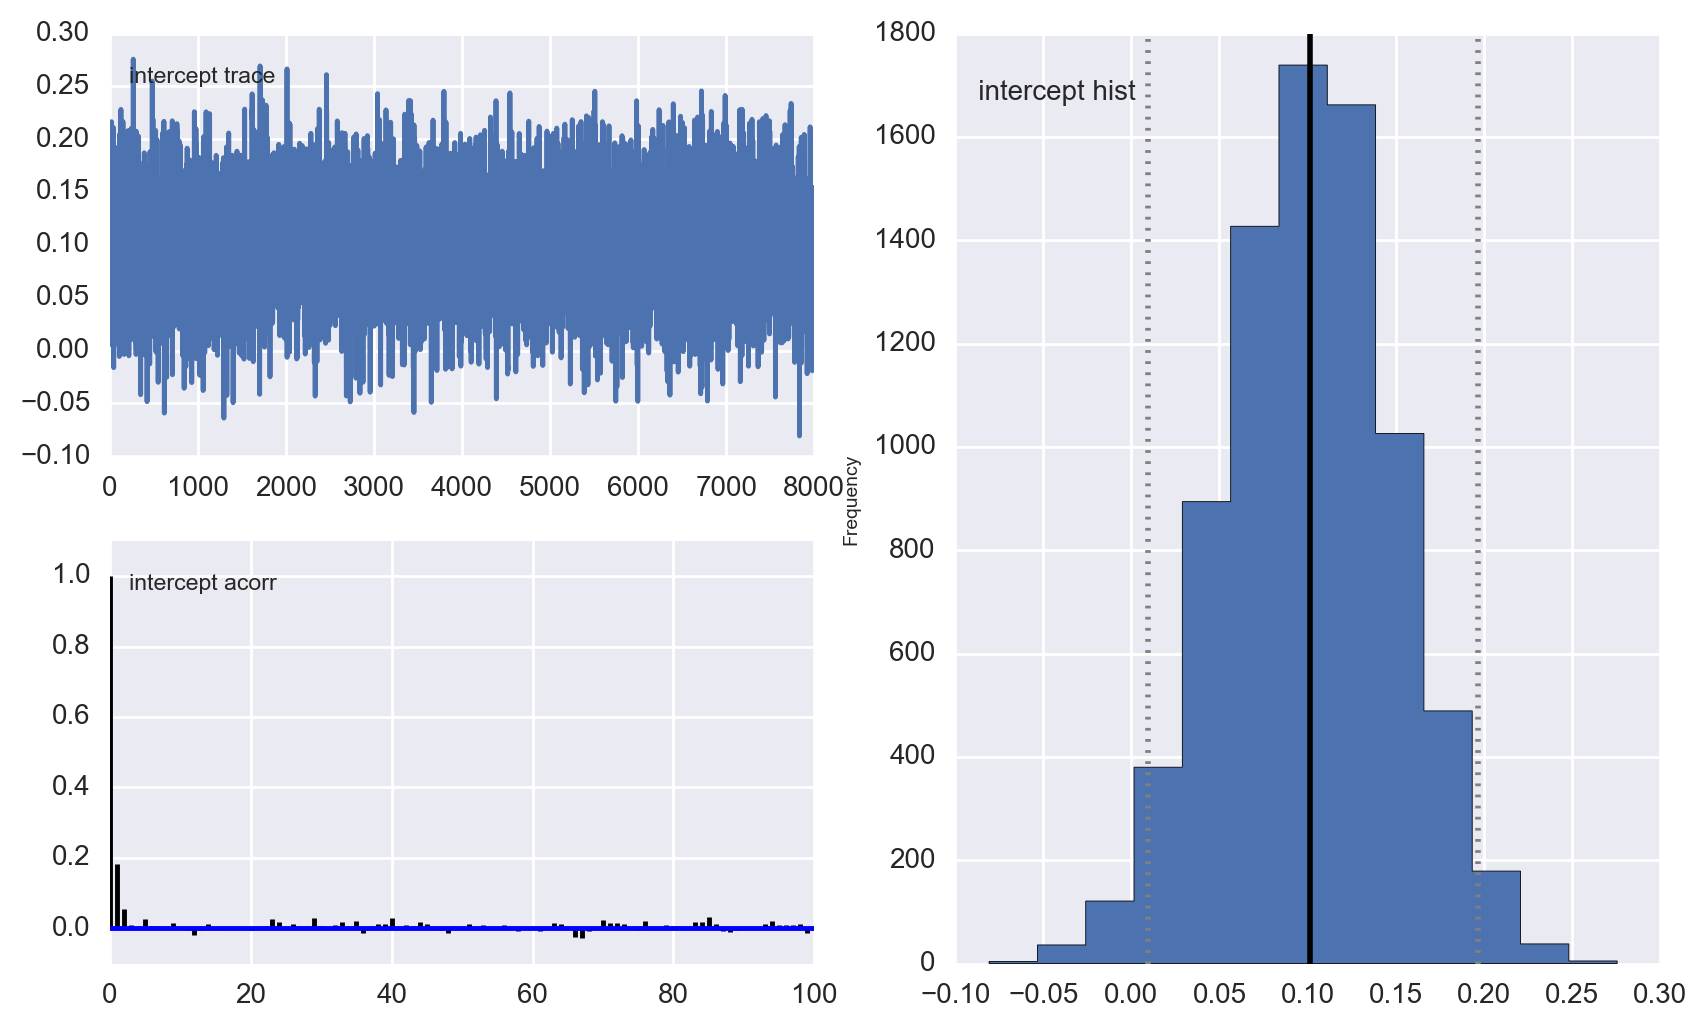

In [41]:
pymc.Matplot.plot(intercept)

Plotting tau_att


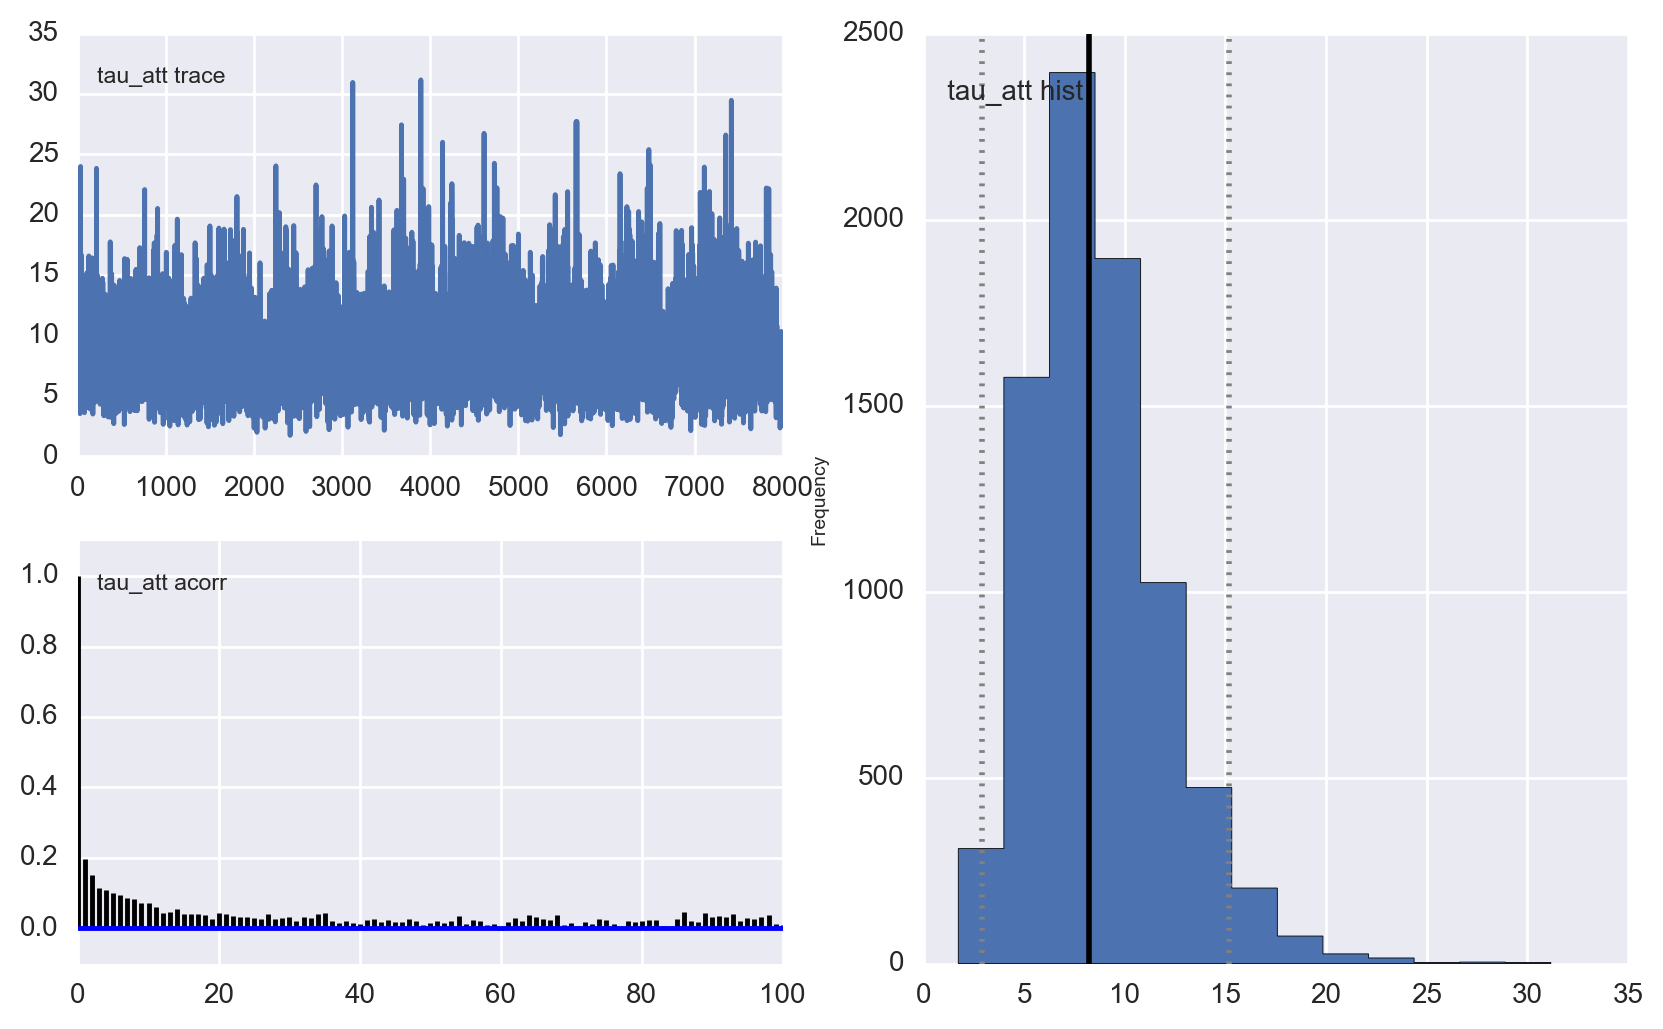

In [42]:
pymc.Matplot.plot(tau_att)

Plotting tau_def


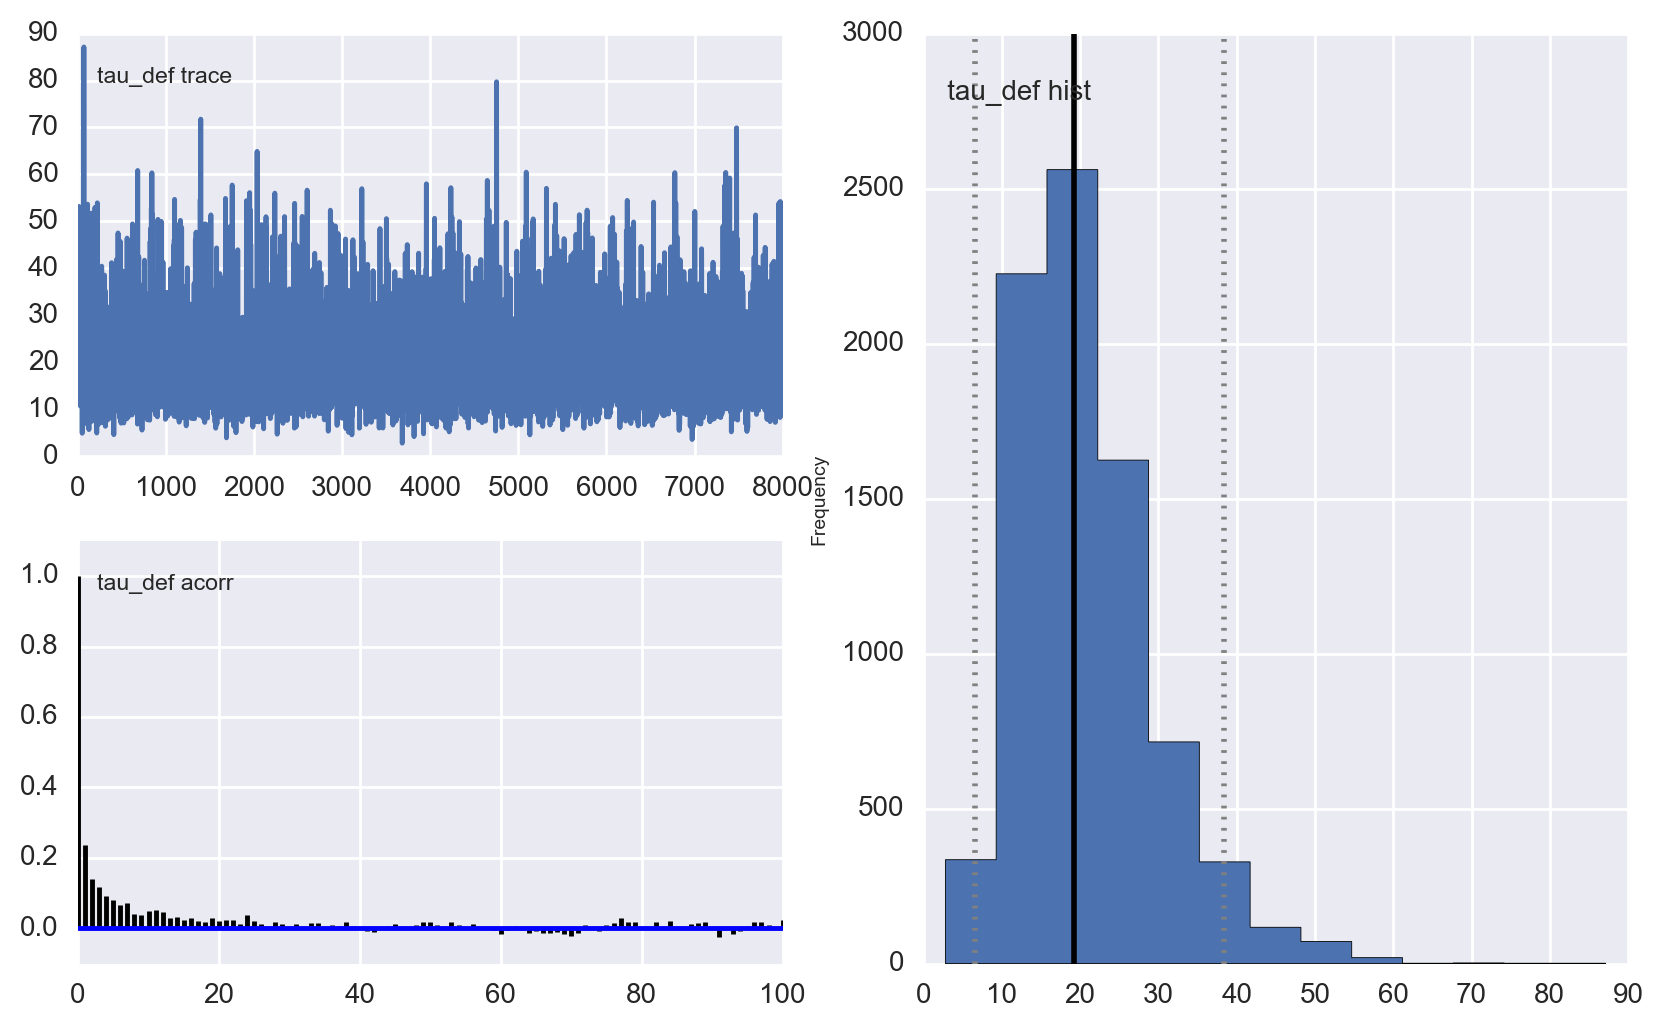

In [43]:
pymc.Matplot.plot(tau_def)

In [48]:
Embed = Image('./atts.png')
Embed